In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Data Loading 

In [2]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# Inspection of Data

In [3]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Conclusion : Need of Encoding 

In [5]:
df.shape

(2000, 8)

In [6]:
df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
(df['answer'].value_counts()/df.shape[0])*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

<Axes: xlabel='answer', ylabel='count'>

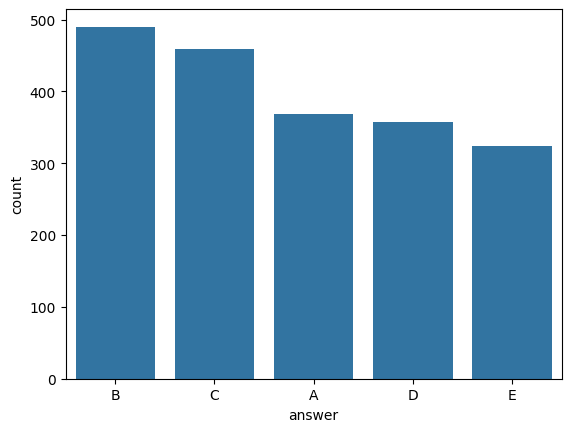

In [9]:
import seaborn as sns

sns.countplot(x=df['answer'], data=df, order=df['answer'].value_counts().index)

In [10]:
x=df['answer'].value_counts().max() +  df['answer'].value_counts().min()

print("Sum of Most frequent and least frequent options in answer column =",x)

Sum of Most frequent and least frequent options in answer column = 814


# Train Test Split

# Data cleaning 
Creating Vocab 
* removing punctuation
* split by space 

In [11]:
import string
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[ True]


In [12]:
import string
def clean_text(text):
    text=text.lower()
    text=text.strip()
    translator=str.maketrans('','',string.punctuation) #nothing,nothing,delete punctuation 
    text=text.translate(translator)
    return text
    

In [13]:
for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)

In [14]:
#verifying 
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[False]


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="answer")
y = df['answer']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Map@3 Metric 


In [16]:
def map3(y_true, top3_preds):
    score = 0

    for actual, pred in zip(y_true, top3_preds):
        if actual == pred[0]:
            score += 1.0

        elif actual == pred[1]:
            score += 0.5

        elif actual == pred[2]:
            score += 1/3

    return score / len(y_true)

# Base line model 

In [17]:
counts = df['answer'].value_counts()

top3 = counts.index[:3].tolist()

print(top3)

['B', 'C', 'A']


In [18]:
y_pred = [top3] * len(X_train)

In [19]:
print("Majority class baseline : ",round(map3(y_train,y_pred),3)) #train dataset and its a dummy classifier

Majority class baseline :  0.421


# Tfidf + cosine similarity 

In [20]:
train_text=pd.concat([
    X_train["prompt"],
    X_train["A"],
    X_train["B"],
    X_train["C"],
    X_train["D"],
    X_train["E"]
])

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer= TfidfVectorizer( ngram_range=(1,3), lowercase=False,
    max_features=80000,
    min_df=2,stop_words="english")
vectorizer.fit(train_text)


TfidfVectorizer(lowercase=False, max_features=80000, min_df=2,
                ngram_range=(1, 3), stop_words='english')

In [22]:
def transform_columns(df,vectorizer):
    return (
        vectorizer.transform(df["prompt"]),
        vectorizer.transform(df["A"]),
        vectorizer.transform(df["B"]),
        vectorizer.transform(df["C"]),
        vectorizer.transform(df["D"]),
        vectorizer.transform(df["E"])
    )

In [23]:
prompt_vec, A_vec, B_vec, C_vec, D_vec, E_vec = transform_columns(X_train, vectorizer)

prompt_val, A_val, B_val, C_val, D_val, E_val = transform_columns(X_val, vectorizer)


In [24]:
from sklearn.metrics.pairwise import cosine_similarity
print("shape of comparing prompt with A_vector",cosine_similarity(prompt_vec, A_vec).diagonal().shape)
scores = {
    'A': cosine_similarity(prompt_vec, A_vec).diagonal(),
    'B': cosine_similarity(prompt_vec, B_vec).diagonal(),
    'C': cosine_similarity(prompt_vec, C_vec).diagonal(),
    'D': cosine_similarity(prompt_vec, D_vec).diagonal(),
    'E': cosine_similarity(prompt_vec, E_vec).diagonal()
}
scores_val = {
    'A': cosine_similarity(prompt_val, A_val).diagonal(),
    'B': cosine_similarity(prompt_val, B_val).diagonal(),
    'C': cosine_similarity(prompt_val, C_val).diagonal(),
    'D': cosine_similarity(prompt_val, D_val).diagonal(),
    'E': cosine_similarity(prompt_val, E_val).diagonal()
}



shape of comparing prompt with A_vector (1600,)


In [25]:
def top3preds(scores_dict):
    preds = []

    for i in range(len(scores_dict["A"])):

        row_scores = {
            "A": scores_dict["A"][i],
            "B": scores_dict["B"][i],
            "C": scores_dict["C"][i],
            "D": scores_dict["D"][i],
            "E": scores_dict["E"][i]
        }

        top3 = []

        for k in range(3):

            best_opt = None
            best_score = -1

            for option, score in row_scores.items():

                if score > best_score:
                    best_score = score
                    best_opt = option

            top3.append(best_opt)
            row_scores.pop(best_opt)

        preds.append(top3)

    return preds

top3_list_val=top3preds(scores_val)
top3_list_train=top3preds(scores)

In [26]:
map3(y_train,top3_list_train)

0.3379166666666659

In [27]:
map3(y_val,top3_list_val)

0.3054166666666664

**Conclusion** Tfidf + cosine similarity gives 0.28 map@3 score on unknown data 

### LR model 
 

In [28]:
from sklearn.linear_model import LogisticRegression

Converting prompt to prompt+option format with label and when prompt and  true option is paired then gives label as 1 . thus converted multiclass labels to binary class labels 

In [29]:
def expand_to_binary(X, y):
    rows = []
    for (idx, row), label in zip(X.iterrows(), y):
        for opt in ['A', 'B', 'C', 'D', 'E']:
            rows.append({
                'text': row['prompt'] + ' ' + row[opt],
                'label': 1 if label == opt else 0
            })
    return pd.DataFrame(rows)


In [30]:

train_binary = expand_to_binary(X_train, y_train)
print("Train binary shape:", train_binary.shape)
print(train_binary['label'].value_counts())


Train binary shape: (8000, 2)
label
0    6400
1    1600
Name: count, dtype: int64


In [31]:

X_train_vec = vectorizer.fit_transform(train_binary['text'])  # fit ONLY on train

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, train_binary['label'])


LogisticRegression(max_iter=1000)

In [32]:

#  INFERENCE 
def predict_top3(row):

    options = ["A", "B", "C", "D", "E"]

    texts = []

    for option in options:
        texts.append(row["prompt"] + " " + row[option])

    probs = lr.predict_proba(vectorizer.transform(texts))[:, 1]

    scores = []

    for i in range(5):
        scores.append((options[i], probs[i]))

    scores.sort(key=lambda x: x[1], reverse=True)

    return [scores[0][0], scores[1][0], scores[2][0]]


In [33]:

top3_val = [predict_top3(row) for _, row in X_val.iterrows()]
print("Validation MAP@3:", round(map3(y_val, top3_val), 4))


Validation MAP@3: 0.9846


## Conclusion of lr model

The **0.9846** validation score reflects lexical memorization of training patterns, not true understanding. The **0.75** leaderboard score reflects real-world generalization.

## Dl model 

In [34]:
import wandb

from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

wandb_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_key)
wandb.init(
    project="23f2005464-t22026",
    name="bert-baseline_new"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f2005464 (23f2005464-iit-madras-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260725_052618-xc0eino0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-baseline_new
wandb: ⭐️ View project at https://wandb.ai/23f2005464-iit-madras-/23f2005464-t22026
wandb: 🚀 View run at https://wandb.ai/23f2005464-iit-madras-/23f2005464-t22026/runs/xc0eino0


In [35]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [36]:
df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

duplicates = df.duplicated(subset=df.columns.drop("id")).sum()
print("Duplicates without id column ",duplicates)

df = df.drop_duplicates(subset=df.columns.drop("id")).reset_index(drop=True)

X = df.drop(columns=["id", "answer"])
y = df["answer"]

print(f"Duplicates after removing: {df.duplicated(subset=df.columns.drop('id')).sum()}")

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Training set",X_train.shape)
print("total shape",X.shape)

Duplicates without id column  183
Duplicates after removing: 0
Training set (1453, 6)
total shape (1817, 6)


In [37]:
import re

def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text
columns = ["prompt", "A", "B", "C", "D", "E"]

for col in columns:
    X_train[col] = X_train[col].apply(clean_text)
    X_val[col] = X_val[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)
    

In [38]:
X_train.columns
print(f"Train size: {len(X_train)} | Val size: {len(X_val)}")

Train size: 1453 | Val size: 364


In [39]:
import transformers
import torch
from transformers import AutoModel, BertTokenizerFast

OPTIONS = ["A", "B", "C", "D", "E"]
LABEL2ID={opt: i for i, opt in enumerate(OPTIONS)}
device = torch.device("cuda")
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [40]:
print("Model Max Length",tokenizer.model_max_length)
print("vocab size",tokenizer.vocab_size)

Model Max Length 512
vocab size 30522


In [41]:
def pairs(df, y=None):
    rows = []

    for i, (_, row) in enumerate(df.iterrows()):
        prompt = row["prompt"]

        for option in ["A", "B", "C", "D", "E"]:

            pair = {
                "prompt": prompt,
                "option": row[option],
                "option_name": option
            }

            if y is not None:
                pair["label"] = int(y.iloc[i] == option)

            rows.append(pair)

    return pd.DataFrame(rows)

In [42]:
train_pairs=pairs(X_train,y_train)
val_pairs=pairs(X_val,y_val)
test_pairs=pairs(test_df)

test_pairs.head()

,prompt,option,option_name
0,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",A
1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",B
2,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",C
3,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",D
4,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",E


Deciding length of token max_length allowed boundary

In [43]:

import numpy as np

lengths = []

for prompt, option in zip(train_pairs["prompt"], train_pairs["option"]):
    tokens = tokenizer.encode(prompt, option, add_special_tokens=True)
    lengths.append(len(tokens))


print("Maximum :", max(lengths))
print("Average :", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("99th percentile:", np.percentile(lengths, 99))

Maximum : 200
Average : 60.34989676531315
95th percentile: 105.0
99th percentile: 131.0


options of max length 64, 128, 256, or 512  AND we are using 128 bcoz our 95 percentage of data is 105 or less.


tokenization 

In [44]:
x_train_encodings= tokenizer(
     train_pairs["prompt"].tolist(),
     train_pairs["option"].tolist(),
     padding="max_length",
     truncation=True,
     max_length=128,
     return_tensors="pt"
          )
x_val_encodings=tokenizer(
   val_pairs["prompt"].tolist(),
    val_pairs["option"].tolist(),
    padding="max_length",
    truncation=True,
     max_length=128,
      return_tensors="pt"
)
test_encodings=tokenizer(
   test_pairs["prompt"].tolist(),
    test_pairs["option"].tolist(),
    padding="max_length",
    truncation=True,
     max_length=128,
      return_tensors="pt"
)
train_labels = torch.tensor(train_pairs["label"].tolist(), dtype=torch.long)
val_labels = torch.tensor(val_pairs["label"].tolist(), dtype=torch.long)

In [45]:
from torch.utils.data import Dataset

class MCQDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

In [46]:
from torch.utils.data import Dataset

class TestDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            key: value[idx]
            for key, value in self.encodings.items()
        }

In [47]:
train_dataset = MCQDataset(
    x_train_encodings,
    train_labels
)

val_dataset = MCQDataset(
    x_val_encodings,
    val_labels
)
test_dataset = TestDataset(test_encodings)

In [48]:
from sklearn.metrics import accuracy_score, f1_score
def map3_score(logits, labels):
    top3_preds = np.argsort(logits, axis=1)[:, -3:][:, ::-1]

    scores = []

    for preds, label in zip(top3_preds, labels):
        if label == preds[0]:
            scores.append(1.0)
        elif label == preds[1]:
            scores.append(0.5)
        elif label == preds[2]:
            scores.append(1/3)
        else:
            scores.append(0.0)

    return np.mean(scores)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {
        "MAP@3": map3_score(logits, labels),
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [49]:
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./mcq_model",

    # Training settings
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    # Saving model
    save_strategy="epoch",
    save_total_limit=2,

    # Learning rate
    learning_rate=2e-5,
    weight_decay=0.01,
    # Logging
    logging_steps=50,

    # Best model selection
    load_best_model_at_end=True,
    

    metric_for_best_model="MAP@3",
    greater_is_better=True,
    # Avoid unnecessary reporting
    report_to="wandb",
   
)

In [50]:
print(type(train_dataset))

<class '__main__.MCQDataset'>


In [51]:
from transformers import BertForSequenceClassification

model=BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [52]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,
     callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Map@3,Accuracy,F1
1,0.988965,0.852438,0.901099,0.802198,0.718324
2,0.563974,0.485226,0.951648,0.903297,0.894175
3,0.331467,0.318920,0.975000,0.950000,0.947825
4,0.173999,0.191501,0.980769,0.961538,0.961418
5,0.170289,0.173852,0.987637,0.975275,0.975484
6,0.087476,0.080067,0.992582,0.985165,0.985063
7,0.069143,0.060500,0.994231,0.988462,0.988407
8,0.059478,0.042480,0.995330,0.990659,0.990674
9,0.027974,0.031551,0.996429,0.992857,0.992839
10,0.008719,0.025424,0.996978,0.993956,0.993959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2280, training_loss=0.2671359361851947, metrics={'train_runtime': 1129.117, 'train_samples_per_second': 64.342, 'train_steps_per_second': 2.019, 'total_flos': 4778754542976000.0, 'train_loss': 0.2671359361851947, 'epoch': 10.0})

# Result of pretrained model 



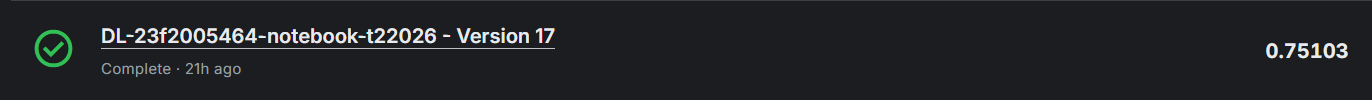

# Model from Scratch 

In [53]:
import pandas as pd
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)


In [54]:
from sklearn.model_selection import train_test_split
duplicates = df.duplicated(subset=df.columns.drop("id")).sum()
print("Duplicates without id column ",duplicates)

df = df.drop_duplicates(subset=df.columns.drop("id")).reset_index(drop=True)

X = df.drop(columns=["id", "answer"])
y = df["answer"]

print(f"Duplicates after removing: {df.duplicated(subset=df.columns.drop('id')).sum()}")

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Training set",X_train.shape)
print("total shape",X.shape)

Duplicates without id column  183
Duplicates after removing: 0
Training set (1453, 6)
total shape (1817, 6)


## Tokenization 

In [55]:
def tokenize(text):
    tokens = text.split()  
    return tokens 


def combine_text(row):
    return (
        row["prompt"] +
        " <SEP> " +
        row["A"] +
        " <SEP> " +
        row["B"] +
        " <SEP> " +
        row["C"] +
        " <SEP> " +
        row["D"] +
        " <SEP> " +
        row["E"]
    )

In [56]:
X_train["text"] = X_train.apply(combine_text, axis=1)
X_train["tokens"]=X_train["text"].apply(tokenize)
X_val["text"]=X_val.apply(combine_text,axis=1)
X_val["tokens"]=X_val["text"].apply(tokenize)
test_df["text"]=test_df.apply(combine_text,axis=1)
test_df["tokens"]=test_df["text"].apply(tokenize)
print(X_train["tokens"].iloc[0])

['Which', 'of', 'the', 'following', 'is', 'correct?', 'What', 'is', 'the', 'reason', 'that', 'it', 'is', 'nearly', 'impossible', 'to', 'see', 'light', 'emitted', 'at', 'the', 'Lyman-alpha', 'transition', 'wavelength', 'from', 'a', 'star', 'farther', 'than', 'a', 'few', 'hundred', 'light', 'years', 'from', 'Earth?', 'from', 'the', 'following', 'choices.', '<SEP>', 'Far', 'ultraviolet', 'light', 'is', 'absorbed', 'effectively', 'by', 'the', 'charged', 'components', 'of', 'the', 'ISM,', 'including', 'atomic', 'helium,', 'which', 'has', 'a', 'typical', 'absorption', 'wavelength', 'of', 'about', '121.5', 'nanometers,', 'the', 'Lyman-alpha', 'transition.', '<SEP>', 'Far', 'ultraviolet', 'light', 'is', 'absorbed', 'effectively', 'by', 'the', 'neutral', 'components', 'of', 'the', 'ISM,', 'including', 'atomic', 'hydrogen,', 'which', 'has', 'a', 'typical', 'absorption', 'wavelength', 'of', 'about', '121.5', 'nanometers,', 'the', 'Lyman-alpha', 'transition.', '<SEP>', 'Far', 'ultraviolet', 'light

## Vocab

In [57]:
from collections import Counter

counter = Counter()

for tokens in X_train["tokens"]:
    counter.update(tokens)

In [58]:
counter.most_common(5)

[('the', 16698), ('of', 10633), ('a', 7901), ('is', 7516), ('<SEP>', 7265)]

In [59]:
vocab={
    "<PAD>":0,
    "<UNK>":1
}
for word in counter:
    vocab[word]=len(vocab)

print("Vocab Size :",len(vocab))

Vocab Size : 3954


In [60]:
def token_to_ids(vocab,tokens):
     result=[]
     for token in tokens : 
         result.append(vocab.get(token,vocab["<UNK>"]))

     return result

In [61]:
X_train["input_ids"]=X_train["tokens"].apply(lambda row:  token_to_ids(vocab,row))
X_val["input_ids"]=X_val["tokens"].apply(lambda row:  token_to_ids(vocab,row))
test_df["input_ids"]=test_df["tokens"].apply(lambda row:  token_to_ids(vocab,row))
print(f"len of token : {len(X_train["tokens"].iloc[1])} \n \ntoken list  : {X_train["tokens"].iloc[1]}")
print(f"\nlen of encoded token :{len(X_train["input_ids"].iloc[1])} \n \nencoded token list  :{X_train["input_ids"].iloc[1]}")

len of token : 86 
 
token list  : ['Determine', 'the', 'correct', 'option:', 'What', 'is', 'the', 'relationship', 'between', 'the', 'amplitude', 'of', 'a', 'sound', 'wave', 'and', 'its', 'loudness?', 'from', 'the', 'following', 'choices.', '<SEP>', 'The', 'amplitude', 'of', 'a', 'sound', 'wave', 'is', 'related', 'to', 'its', 'loudness.', '<SEP>', 'The', 'amplitude', 'of', 'a', 'sound', 'wave', 'is', 'directly', 'proportional', 'to', 'its', 'frequency.', '<SEP>', 'The', 'amplitude', 'of', 'a', 'sound', 'wave', 'is', 'not', 'related', 'to', 'its', 'loudness.', '<SEP>', 'The', 'amplitude', 'of', 'a', 'sound', 'wave', 'is', 'not', 'related', 'to', 'its', 'frequency.', '<SEP>', 'The', 'amplitude', 'of', 'a', 'sound', 'wave', 'is', 'inversely', 'related', 'to', 'its', 'loudness.']

len of encoded token :86 
 
encoded token list  :[55, 4, 56, 57, 8, 6, 4, 58, 59, 4, 60, 3, 23, 61, 62, 63, 64, 65, 22, 4, 5, 31, 32, 66, 60, 3, 23, 61, 62, 6, 67, 14, 64, 68, 32, 66, 60, 3, 23, 61, 62, 6, 69, 70

In [62]:
X_train["length"] = X_train["input_ids"].map(len)
X_train["length"].describe()

count    1453.000000
mean      154.699931
std        84.599352
min        22.000000
25%        92.000000
50%       138.000000
75%       208.000000
max       462.000000
Name: length, dtype: float64

In [63]:
max_length = 256
def pad_truncate(input_ids):
    if len(input_ids) >= max_length:
        return input_ids[:max_length]
    
    while len(input_ids) < max_length:
        input_ids.append(vocab["<PAD>"])

    return input_ids

In [64]:
X_train["input_ids"] = X_train["input_ids"].map(pad_truncate)
X_val["input_ids"]=X_val["input_ids"].map(pad_truncate)
test_df["input_ids"]=test_df["input_ids"].map(pad_truncate)

In [65]:
print(len(X_train["input_ids"].iloc[0]))

256


In [66]:
X_train.shape


(1453, 10)

In [67]:
label2int = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4
}

y_train = y_train.map(label2int)
y_val=y_val.map(label2int)

In [68]:
def overlap_score(prompt_tokens, option_tokens):
    return len(set(prompt_tokens) & set(option_tokens))

def predict_by_overlap(row):
    prompt_toks = set(row["prompt"].split())
    scores = []
    for opt in ["A", "B", "C", "D", "E"]:
        opt_toks = set(row[opt].split())
        scores.append(len(prompt_toks & opt_toks))
    return scores.index(max(scores))

preds = X_val.apply(predict_by_overlap, axis=1)
acc = (preds.values == y_val.values).mean()
print("Overlap-only baseline accuracy:", acc)

Overlap-only baseline accuracy: 0.17582417582417584


In [69]:
import numpy as np
# Is the correct answer systematically the longest/shortest option?
df["ans_len"] = df.apply(lambda r: len(r[r["answer"]].split()), axis=1)
df["other_len_avg"] = df.apply(lambda r: np.mean([len(r[c].split()) for c in "ABCDE" if c != r["answer"]]), axis=1)
print((df["ans_len"] > df["other_len_avg"]).mean())

0.6070445789763346


In [70]:
def combine_options_only(row):
    return " <SEP> ".join([row["A"], row["B"], row["C"], row["D"], row["E"]])

# quick logistic regression sanity check (fast, no need to retrain CNN)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

opt_text_train = X_train.apply(combine_options_only, axis=1)
opt_text_val = X_val.apply(combine_options_only, axis=1)

vec = TfidfVectorizer()
Xtr = vec.fit_transform(opt_text_train)
Xva = vec.transform(opt_text_val)

clf = LogisticRegression(max_iter=1000).fit(Xtr, y_train)
print("Options-only accuracy:", clf.score(Xva, y_val))

Options-only accuracy: 1.0


In [71]:
# Compare basic stats of correct vs incorrect options
df["correct_text"] = df.apply(lambda r: r[r["answer"]], axis=1)
df["correct_len"] = df["correct_text"].str.len()
df["correct_wordcount"] = df["correct_text"].str.split().str.len()

incorrect_lens = []
incorrect_wc = []
for _, r in df.iterrows():
    for c in "ABCDE":
        if c != r["answer"]:
            incorrect_lens.append(len(r[c]))
            incorrect_wc.append(len(r[c].split()))

print("Correct avg char len:", df["correct_len"].mean(), "  Incorrect avg char len:", np.mean(incorrect_lens))
print("Correct avg word count:", df["correct_wordcount"].mean(), "  Incorrect avg word count:", np.mean(incorrect_wc))

# Check most predictive words/features from the logistic regression itself
import numpy as np
feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_  # shape (5, n_features) for multiclass
for class_idx, label in enumerate(["A","B","C","D","E"]):
    top_idx = np.argsort(coefs[class_idx])[-15:]
    print(f"\nTop features predicting label={label}:")
    print(feature_names[top_idx])

Correct avg char len: 182.2548156301596   Incorrect avg char len: 161.19386351128233
Correct avg word count: 28.71491469455146   Incorrect avg word count: 25.768436984039624

Top features predicting label=A:
['antiquarks' 'adopted' 'phenomenon' 'airfoil' 'particles' 'five' 'wigner'
 'quarks' 'dimension' 'petroleum' 'eigenstate' 'identity' 'statements'
 'density' 'language']

Top features predicting label=B:
['anatomy' 'study' 'sun' 'involves' 'rotation' 'ratio' 'unit' '12' '14'
 'hand' '10' 'emission' 'atmosphere' 'power' 'amount']

Top features predicting label=C:
['well' 'shape' 'gravitational' 'field' 'energy' 'how' 'forced' 'group'
 'hole' 'theorem' 'per' 'convection' 'black' 'in' 'einstein']

Top features predicting label=D:
['ut1' 'distance' 'standard' 'diffraction' 'variables' 'object' 'utc'
 'resonant' 'change' 'temperature' 'mass' 'parity' 'parameter' 'depends'
 'on']

Top features predicting label=E:
['indicate' 'elementary' 'isophotal' 'coffee' 'function' 'mechanics'
 'recip

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Check duplication WITHIN the whole dataset (not just train vs val)
vec_all = TfidfVectorizer().fit(df["prompt"])
X_all = vec_all.transform(df["prompt"])
sims = cosine_similarity(X_all)
np.fill_diagonal(sims, 0)
max_sim_per_row = sims.max(axis=1)
print("Rows with >0.9 similarity to another row:", (max_sim_per_row > 0.9).sum(), "/", len(df))
print("Rows with >0.7 similarity to another row:", (max_sim_per_row > 0.7).sum(), "/", len(df))

# 2. Check if specific topic words map near-deterministically to a fixed answer letter
for word in ["quarks", "black", "quantum", "gravitational", "airfoil"]:
    mask = df["prompt"].str.lower().str.contains(word) | df[["A","B","C","D","E"]].apply(
        lambda r: r.str.lower().str.contains(word).any(), axis=1
    )
    print(word, "->", df.loc[mask, "answer"].value_counts().to_dict())

Rows with >0.9 similarity to another row: 1412 / 1817
Rows with >0.7 similarity to another row: 1807 / 1817
quarks -> {'A': 18}
black -> {'C': 49, 'A': 18, 'E': 8, 'B': 7}
quantum -> {'E': 55, 'A': 39, 'D': 14, 'B': 7, 'C': 7}
gravitational -> {'C': 79, 'D': 14, 'B': 10, 'A': 9, 'E': 8}
airfoil -> {'A': 11}


In [73]:
import torch
from torch.utils.data import Dataset


class MCQDataset(Dataset):

    def __init__(self, input_ids, labels):

        self.input_ids = input_ids
        self.labels = labels

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):

        return {
            "input_ids": torch.tensor(
                self.input_ids.iloc[index],
                dtype=torch.long
            ),

            "labels": torch.tensor(
                self.labels.iloc[index],
                dtype=torch.long
            )
        }

In [74]:
train_dataset=MCQDataset( X_train["input_ids"],y_train)
validation_dataset=MCQDataset( X_val["input_ids"],y_val)
print(y_train.head())
print(y_train.dtype)

print(y_val.head())
print(y_val.dtype)

1547    1
339     0
35      3
956     1
1776    3
Name: answer, dtype: int64
int64
1104    0
960     0
1623    4
1414    3
666     3
Name: answer, dtype: int64
int64


In [75]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False
)

batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["labels"].shape)


torch.Size([32, 256])
torch.Size([32])


In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

In [77]:
class TextCNN(nn.Module):

    def __init__(self,
                 vocab_size,
                 embedding_dim,
                 num_classes):

        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Convolution layers
        self.conv3 = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=100,
            kernel_size=3
        )

        self.conv4 = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=100,
            kernel_size=4
        )

        self.conv5 = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=100,
            kernel_size=5
        )

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Fully connected layer
        self.fc = nn.Linear(
            300,
            num_classes
        )

    def forward(self, input_ids):

        # Convert token ids to embeddings
        x = self.embedding(input_ids)

        # Change shape:
        # (batch, seq_len, embed_dim)
        # ->
        # (batch, embed_dim, seq_len)

        x = x.permute(0, 2, 1)

        # Convolution + ReLU
        conv3 = F.relu(self.conv3(x))
        conv4 = F.relu(self.conv4(x))
        conv5 = F.relu(self.conv5(x))

        # Global Max Pooling
        pool3 = F.max_pool1d(conv3, conv3.shape[2]).squeeze(2)
        pool4 = F.max_pool1d(conv4, conv4.shape[2]).squeeze(2)
        pool5 = F.max_pool1d(conv5, conv5.shape[2]).squeeze(2)

        # Concatenate
        x = torch.cat(
            (pool3, pool4, pool5),
            dim=1
        )

        x = self.dropout(x)

        output = self.fc(x)

        return output

In [78]:
model = TextCNN(
    vocab_size=len(vocab),
    embedding_dim=300,
    num_classes=5
)

In [79]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

In [80]:
criterion = torch.nn.CrossEntropyLoss()

In [81]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [82]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["labels"].shape)

torch.Size([32, 256])
torch.Size([32])


In [83]:
    epochs=5
    for epoch in range(epochs) :
    
        model.train()
        total_train_loss=0
        for step, batch in enumerate(train_loader, start=1):
      
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
    
            outputs = model(input_ids)
    
            loss = criterion(outputs, labels)
            total_train_loss+=loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        average_train_loss=total_train_loss/len(train_loader)
        
        #Validation 
        model.eval()
        all_logits = []
        all_labels = []

        total_val_loss =0
        correct=0
        total=0
        with torch.no_grad():
            for step, batch in enumerate(valid_loader,start=1):
                input_ids=batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
    
                outputs = model(input_ids)
                    
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                all_logits.append(outputs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
            average_val_loss = total_val_loss / len(valid_loader)
            accuracy = (correct / total) * 100
        
        
        all_logits = np.concatenate(all_logits, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        
        map3 = map3_score(all_logits, all_labels)
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss      : {average_train_loss:.4f}")
        print(f"Validation Loss : {average_val_loss:.4f}")
        print(f"Validation Acc  : {accuracy:.2f}%")
        print(f"Validation MAP@3: {map3:.4f}")

Epoch 1/5
Train Loss      : 1.0081
Validation Loss : 0.2097
Validation Acc  : 99.73%
Validation MAP@3: 0.9986
Epoch 2/5
Train Loss      : 0.1886
Validation Loss : 0.0368
Validation Acc  : 100.00%
Validation MAP@3: 1.0000
Epoch 3/5
Train Loss      : 0.0630
Validation Loss : 0.0121
Validation Acc  : 100.00%
Validation MAP@3: 1.0000
Epoch 4/5
Train Loss      : 0.0369
Validation Loss : 0.0059
Validation Acc  : 100.00%
Validation MAP@3: 1.0000
Epoch 5/5
Train Loss      : 0.0225
Validation Loss : 0.0036
Validation Acc  : 100.00%
Validation MAP@3: 1.0000


In [84]:
train_text = X_train["text"].reset_index(drop=True)
val_text = X_val["text"].reset_index(drop=True)

duplicates = val_text.isin(set(train_text)).sum()

print("Duplicate validation samples:", duplicates)
print("Validation samples:", len(val_text))

Duplicate validation samples: 0
Validation samples: 364


In [85]:
class TestDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(
                self.df.iloc[idx]["input_ids"],
                dtype=torch.long
            )
        }

In [86]:
test_dataset = TestDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [87]:
model.eval()

all_predictions = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        outputs = model(input_ids)

        top3 = torch.topk(outputs, k=3, dim=1).indices

        all_predictions.extend(top3.cpu().numpy())

In [88]:
label_map = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "E"
}

predictions = [
    " ".join(label_map[i] for i in pred)
    for pred in all_predictions
]

In [89]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "prediction": predictions
})

submission.to_csv("submission.csv", index=False)